# Create A Linear Regression Model Using R

## Load Libraries
- ggplot2 → for visualisation
- dplyr → for data manipulation
- caret → for train/test splitting and evaluation

In [19]:
# List of Need Libaries
required_packages <- c(
  "ggplot2", "dplyr", "caret"
)

# Install
installed <- rownames(installed.packages())

# Check if Library is installed
for (pkg in required_packages) {
  if (!pkg %in% installed) install.packages(pkg)
}

# Add Libraies
library(ggplot2)
library(dplyr)
library(caret)

## Load Dataset

In [20]:
# This dataset contains monthly crime totals along with weather variables from Github
data <- read.csv("https://raw.githubusercontent.com/bcroman/21006366_DA_Assessment/refs/heads/main/Data/monthly_totals.csv")

## Explore Dataset
- summary() → gives statistical overview
- str() → shows data types
- head() → shows first few rows

In [21]:
summary(data)
str(data)
head(data)

      year          month       crime_month         total_crime   
 Min.   :2014   Min.   : 1.00   Length:36          Min.   :51222  
 1st Qu.:2014   1st Qu.: 3.75   Class :character   1st Qu.:57012  
 Median :2015   Median : 6.50   Mode  :character   Median :59007  
 Mean   :2015   Mean   : 6.50                      Mean   :59109  
 3rd Qu.:2016   3rd Qu.: 9.25                      3rd Qu.:61460  
 Max.   :2016   Max.   :12.00                      Max.   :65519  
                                                                  
    avg_temp        avg_dewp        avg_slp       avg_visib      
 Min.   :40.81   Min.   :35.19   Min.   :9690   Min.   :  4.465  
 1st Qu.:45.21   1st Qu.:39.36   1st Qu.:9695   1st Qu.:  5.944  
 Median :52.89   Median :46.56   Median :9700   Median :  6.332  
 Mean   :53.50   Mean   :45.49   Mean   :9700   Mean   : 19.730  
 3rd Qu.:61.65   3rd Qu.:51.52   3rd Qu.:9705   3rd Qu.: 14.549  
 Max.   :67.73   Max.   :55.60   Max.   :9710   Max.   :106.073  
  

'data.frame':	36 obs. of  17 variables:
 $ year        : int  2014 2014 2014 2014 2014 2014 2014 2014 2014 2014 ...
 $ month       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ crime_month : chr  "2014-01-01" "2014-02-01" "2014-03-01" "2014-04-01" ...
 $ total_crime : int  55515 51222 57669 53467 56327 57039 58564 55641 56933 60537 ...
 $ avg_temp    : num  44.6 45.4 48.1 52.9 56.6 ...
 $ avg_dewp    : num  40.4 38.9 39.5 44 46.7 ...
 $ avg_slp     : num  NA NA NA NA NA ...
 $ avg_visib   : num  5.97 6.54 37.71 5.81 38.39 ...
 $ avg_wdsp    : num  9.37 12.25 7.65 7.26 7.83 ...
 $ avg_mxpsd   : num  16.2 20.1 14 12.5 13.1 ...
 $ avg_gust    : num  466 308 717 805 591 ...
 $ avg_max_temp: num  50.1 51.1 57.5 61.1 64.4 ...
 $ avg_min_temp: num  38.6 39.6 39.9 44.9 48.8 ...
 $ avg_prcp    : num  0.188 0.145 0.041 0.074 0.112 ...
 $ avg_sndp    : logi  NA NA NA NA NA NA ...
 $ fog_days    : int  5 1 7 4 0 1 0 1 2 4 ...
 $ month_factor: chr  "Jan" "Feb" "Mar" "Apr" ...


,year,month,crime_month,total_crime,avg_temp,avg_dewp,avg_slp,avg_visib,avg_wdsp,avg_mxpsd,avg_gust,avg_max_temp,avg_min_temp,avg_prcp,avg_sndp,fog_days,month_factor
,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>
1,2014,1,2014-01-01,55515,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan
2,2014,2,2014-02-01,51222,45.41786,38.94643,NA,6.542857,12.246429,20.12500,308.4607,51.11071,39.59286,0.14464286,NA,1,Feb
3,2014,3,2014-03-01,57669,48.12258,39.50000,NA,37.709677,7.651613,13.95806,716.6065,57.52258,39.90645,0.04096774,NA,7,Mar
4,2014,4,2014-04-01,53467,52.87000,43.99333,NA,5.813333,7.263333,12.49333,804.8167,61.07333,44.89667,0.07400000,NA,4,Apr
5,2014,5,2014-05-01,56327,56.64516,46.74839,NA,38.387097,7.832258,13.13548,591.4871,64.39032,48.81613,0.11193548,NA,0,May
6,2014,6,2014-06-01,57039,62.91333,50.29000,NA,106.073333,6.290000,11.59667,674.4000,71.98333,53.97000,0.05333333,NA,1,Jun


## Define Target and Features

In [22]:
#Target variable (what we want to predict)
target <- "total_crime"

# Feature variables (predictors): These include weather and time-related variables
features <- c("year", "month", "avg_temp",  "avg_dewp",  "avg_visib", "avg_wdsp",
              "avg_mxpsd", "avg_gust", "avg_max_temp", "avg_min_temp",
              "avg_prcp", "fog_days")

## Split data into training and testing sets
80% training → used to build model  
20% testing → used to evaluate model performance

In [23]:
set.seed(123)

train_index <- createDataPartition(data$total_crime, p = 0.8, list = FALSE)
train_data <- data[train_index, ]
test_data  <- data[-train_index, ]

## Create the linear regression model

In [24]:
#The model predicts total_crime using selected features
model <- lm(as.formula(paste(target, "~", paste(features, collapse = " + "))), data = train_data)

# View model summary like coefficients and significance
summary(model)


Call:
lm(formula = as.formula(paste(target, "~", paste(features, collapse = " + "))), 
    data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-3452.8 -1463.3  -111.5  1493.7  3899.9 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)  
(Intercept)  -4.592e+06  1.725e+06  -2.661   0.0154 *
year          2.303e+03  8.526e+02   2.701   0.0142 *
month         3.580e+02  1.714e+02   2.089   0.0504 .
avg_temp      1.887e+02  2.797e+03   0.067   0.9469  
avg_dewp     -3.869e+01  6.065e+02  -0.064   0.9498  
avg_visib     5.479e+00  2.199e+01   0.249   0.8059  
avg_wdsp      1.179e+03  2.358e+03   0.500   0.6228  
avg_mxpsd    -6.678e+02  1.746e+03  -0.382   0.7064  
avg_gust     -2.320e+00  7.831e+00  -0.296   0.7703  
avg_max_temp  4.685e+01  1.240e+03   0.038   0.9703  
avg_min_temp -6.232e+01  1.862e+03  -0.033   0.9736  
avg_prcp      2.512e+01  9.735e+01   0.258   0.7991  
fog_days      2.702e+02  3.083e+02   0.876   0.3917  
---
Signif. codes:  0 ‘*

## Predictions

In [25]:
# Generate predictions on test data
predictions <- predict(model, newdata = test_data)

## Model Evaluation

In [26]:
# RMSE → measures prediction error (lower is better)
rmse <- sqrt(mean((test_data$total_crime - predictions)^2))
# MAE → average absolute error
mae  <- mean(abs(test_data$total_crime - predictions))
# R-squared → how well model explains variation
r2   <- cor(test_data$total_crime, predictions)^2

# Print Results
cat("RMSE:", rmse, "\n")
cat("MAE:", mae, "\n")
cat("R-squared:", r2, "\n")

RMSE: 2190.714 
MAE: 1842.202 
R-squared: 0.6208879 


## Compare Actual vs Predicted

,Actual,Predicted
,<int>,<dbl>
5,56327,56323.31
13,57055,55454.39
22,62361,59579.13
33,61412,64394.64


`geom_smooth()` using formula = 'y ~ x'


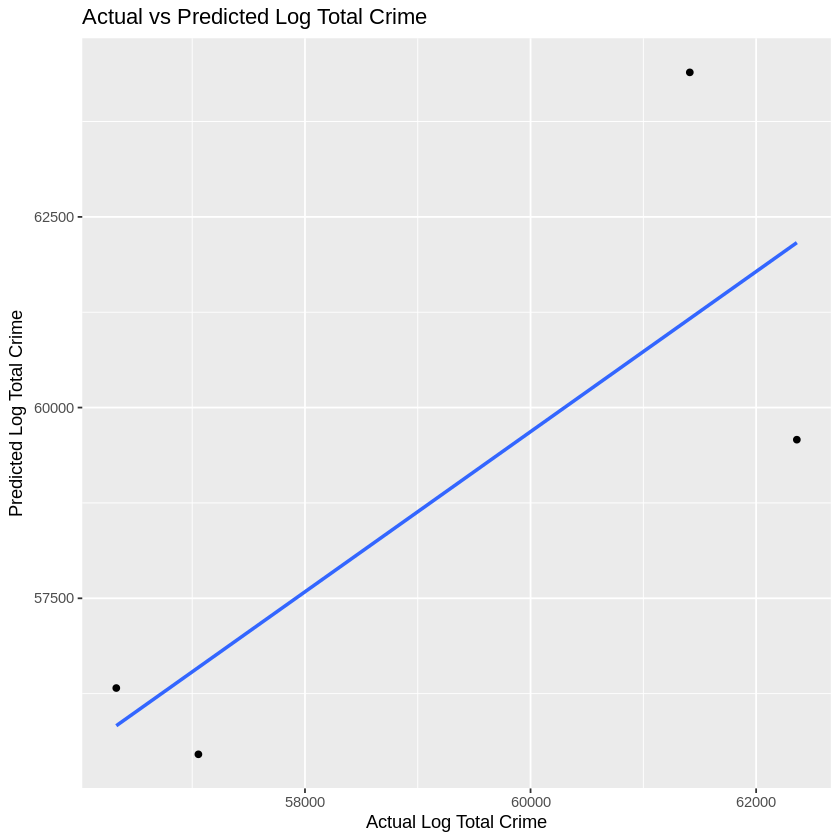

In [27]:
# Helps assess how well predictions match real data
results <- data.frame(
  Actual = test_data$total_crime,
  Predicted = predictions
)
head(results)

# Visualize Chart
ggplot(results, aes(x = Actual, y = Predicted)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Actual vs Predicted Log Total Crime",
    x = "Actual Log Total Crime",
    y = "Predicted Log Total Crime"
  )

## Model Diagnostics

Used to check model assumptions:
- linearity
- normality
- homoscedasticity

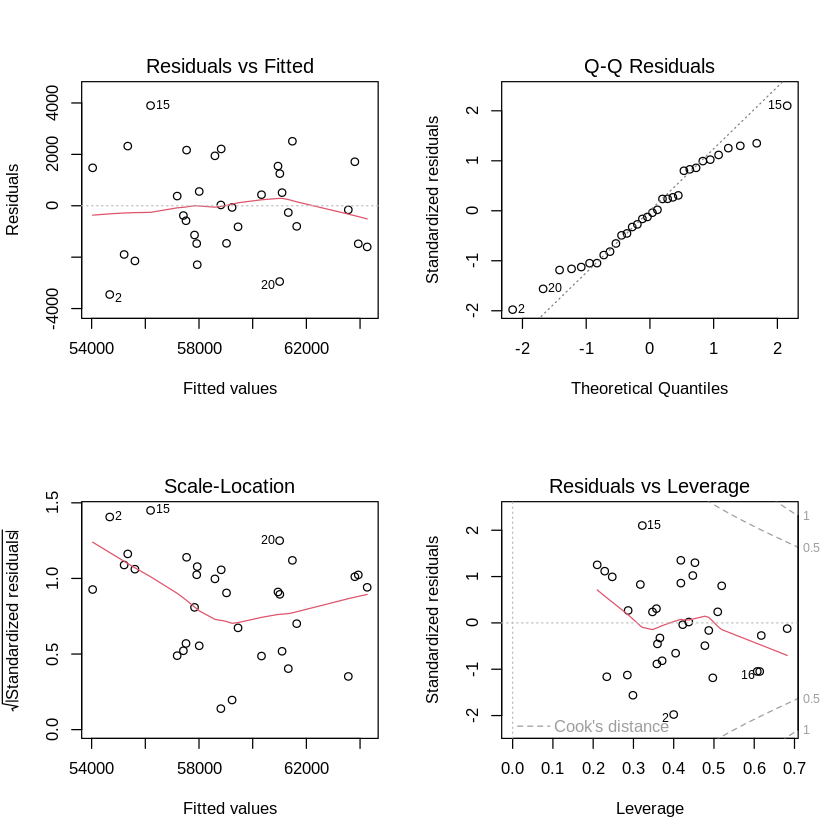

In [28]:
par(mfrow = c(2, 2))
plot(model)